In [1]:
from typing import TypedDict, List, Annotated
from langgraph.graph import add_messages
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage
import subprocess
import re
import time
import ast
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from databricks_langchain import ChatDatabricks

llm = ChatDatabricks(
    endpoint="databricks-meta-llama-3-3-70b-instruct",
    temperature=0,
    max_tokens=4096
)


def call_llm_with_retry(messages, max_retries=3):
    """Retry LLM calls on connection errors."""
    for attempt in range(max_retries):
        try:
            return llm.invoke(messages)
        except Exception as e:
            if attempt < max_retries - 1:
                print(f"LLM attempt {attempt+1} failed. Retrying in 5s...")
                time.sleep(5)
            else:
                raise e

c:\Users\Usama Azam\Desktop\databricks-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class GameState(TypedDict):
    director_messages:  Annotated[List[AnyMessage], add_messages]
    architect_messages: Annotated[List[AnyMessage], add_messages]
    engineer_code:      Annotated[List[AnyMessage], add_messages]
    qa_feedback:        Annotated[List[AnyMessage], add_messages]
    current_actor:      str
    iteration:          int
    iteration_score:    List[float]
    file_saved:         bool

In [4]:
class QASubgraphState(TypedDict):
    code:          str
    requirements:  str
    syntax_report: str
    logic_report:  str
    final_score:   float
    qa_summary:    str

In [5]:
def director_node(state: GameState):
    director_msg = HumanMessage(
        content=input("Awaiting Director Prompt: ")
    )
    return {
        "director_messages": [director_msg],
        "current_actor":     "director"
    }

In [6]:
def architect_node(state: GameState):
    director_req = state["director_messages"][-1].content
    prompt = f"""You are a senior software architect specializing in 2D game development using Python and Pygame.

The director has given the following requirement:
{director_req}

Produce a DETAILED system design covering:
1. Classes (Player, Cactus, Pterodactyl, Game, ScoreManager)
2. Game loop structure
3. Physics system (gravity, jump, duck)
4. Obstacle system (cacti and pterodactyls)
5. Scoring system with file persistence
6. Game states (start, running, game over)
7. Technical requirements (Python 3.x, Pygame)

Be specific. The engineer will use this directly.
"""
    response = call_llm_with_retry([
        SystemMessage(content="You are a senior software architect."),
        HumanMessage(content=prompt)
    ])
    return {
        "architect_messages": [response],
        "current_actor":      "architect"
    }

In [7]:
def engineer_node(state: GameState):
    architect_design = state["architect_messages"][-1].content
    
    qa_report = ""
    if state["qa_feedback"]:
        qa_report = f"""
PREVIOUS QA FEEDBACK — FIX THESE ISSUES:
{state["qa_feedback"][-1].content}
"""
    
    engineer_prompt = f"""You are a senior Python game developer.

DESIGN:
{architect_design}

{qa_report}

Write COMPLETE working Python game with:
1. Player with smooth jumping (only from ground), ducking (DOWN key)
2. Ground obstacles (Cacti) - 3 sizes, jumpable height
3. Flying obstacles (Pterodactyls) - 3 fixed heights
4. Minimum 90 frame gap between obstacles
5. Collision detection using pygame.Rect.colliderect
6. Score system saved to high_score.txt
7. Speed increases every 200 points
8. Start screen, game over screen, restart with R or SPACE
9. Single file, no external assets, Pygame only
10. Screen 800x300, FPS 60

IMPORTANT: Return ONLY Python code. No markdown. Start with: import pygame
"""
    
    response = call_llm_with_retry([
        SystemMessage(content="Senior Python game developer. Return only working code."),
        HumanMessage(content=engineer_prompt)
    ])
    return {
        "engineer_code":  [response],
        "current_actor":  "engineer"
    }

In [8]:
def file_writer(state: GameState):
    code = state["engineer_code"][-1].content
    code = code.replace("```python", "").replace("```", "").strip()
    
    with open("dino_runner.py", "w", encoding="utf-8") as f:
        f.write(code)
    
    print("[File saved: dino_runner.py]")
    return {
        "file_saved":    True,
        "current_actor": "file_io"
    }

In [17]:
def run_code(state: GameState):
    print("\n===== CODE EXECUTION =====")
    choice = input("Run the generated game? (y/n): ").strip().lower()
    
    if choice != "y":
        return {
            "qa_feedback":   [AIMessage(content="Execution cancelled by human.")],
            "file_saved":    False,
            "current_actor": "execution"
        }
    
    print("\nExecuting dino_runner.py...")
    try:
        result = subprocess.run(
            ["python", "dino_runner.py"],
            capture_output=True,
            text=True,
            timeout=10
        )
        output = result.stdout + result.stderr
        if not output:
            output = "Game window opened — no output captured"
    except subprocess.TimeoutExpired:
        output = "Game ran for 10 seconds — likely working correctly"
    except Exception as e:
        output = f"Execution failed: {str(e)}"
    
    print("[Execution Output]:", output)
    return {
        "qa_feedback":   [AIMessage(content=f"Execution output:\n{output}")],
        "current_actor": "execution"
    }

In [9]:
def syntax_checker_node(state: QASubgraphState):
    code = state["code"]
    code_clean = code.replace("```python", "").replace("```", "").strip()
    
    try:
        ast.parse(code_clean)
        report = "SYNTAX CHECK: PASSED — no syntax errors"
    except SyntaxError as e:
        report = f"SYNTAX CHECK: FAILED — line {e.lineno}: {e.msg}"
    
    print(f"[Syntax Checker]: {report}")
    return {"syntax_report": report}

In [10]:
def logic_tester_node(state: QASubgraphState):
    prompt = f"""You are a game logic tester.

REQUIREMENTS:
{state["requirements"]}

CODE:
{state["code"]}

Test these logic points and respond PASS or FAIL with one sentence:

1. Player jumps only from ground (no double jump)?
2. Duck reduces hitbox correctly?
3. Cacti spawn at ground level?
4. Pterodactyls spawn at different heights?
5. Collision detection uses pygame.Rect.colliderect or equivalent?
6. High score saves and loads from file?
7. Game over triggers on collision?
8. Restart works with R or SPACE?
9. Speed increases over time?
10. Min gap between obstacles enforced?

Format: number. PASS/FAIL — reason
"""
    response = call_llm_with_retry([
        SystemMessage(content="Game logic tester. Test each point with PASS/FAIL."),
        HumanMessage(content=prompt)
    ])
    
    print("[Logic Tester]: Done")
    return {"logic_report": response.content}

In [11]:
def performance_auditor_node(state: QASubgraphState):
    prompt = f"""You are a code performance auditor.

SYNTAX REPORT:
{state["syntax_report"]}

LOGIC REPORT:
{state["logic_report"]}

Based on both reports give:
1. A score from 1 to 10 (decimals allowed e.g. 7.5)
2. Brief summary of overall code quality

Format your response EXACTLY:
SCORE: 8.5
SUMMARY: brief description here
"""
    response = call_llm_with_retry([
        SystemMessage(content="Performance auditor. Use exact format."),
        HumanMessage(content=prompt)
    ])
    
    content = response.content
    score   = 5.0
    summary = content
    
    for line in content.split("\n"):
        if line.upper().startswith("SCORE:"):
            numbers = re.findall(r'\d+\.?\d*', line)
            if numbers:
                score = max(1.0, min(10.0, float(numbers[0])))
        if line.upper().startswith("SUMMARY:"):
            summary = line.split(":", 1)[1].strip()
    
    qa_summary = f"""=== QA SUBGRAPH REPORT ===

{state["syntax_report"]}

LOGIC TEST:
{state["logic_report"]}

PERFORMANCE AUDIT:
Score: {score}/10
{summary}
"""
    
    print(f"[Performance Auditor]: Score {score}/10")
    return {
        "final_score": score,
        "qa_summary":  qa_summary
    }

In [18]:
qa_builder = StateGraph(QASubgraphState)

qa_builder.add_node("syntax_checker",      syntax_checker_node)
qa_builder.add_node("logic_tester",        logic_tester_node)
qa_builder.add_node("performance_auditor", performance_auditor_node)

qa_builder.add_edge(START,                 "syntax_checker")
qa_builder.add_edge("syntax_checker",      "logic_tester")
qa_builder.add_edge("logic_tester",        "performance_auditor")
qa_builder.add_edge("performance_auditor", END)

qa_subgraph = qa_builder.compile()

print("QA Subgraph compiled!")

QA Subgraph compiled!


In [19]:
def qa_wrapper_node(state: GameState):
    """Wrapper that calls QA subgraph from parent graph."""
    
    # Transform parent state → subgraph state
    subgraph_input = {
        "code":         state["engineer_code"][-1].content,
        "requirements": state["architect_messages"][-1].content,
        "syntax_report": "",
        "logic_report":  "",
        "final_score":   0.0,
        "qa_summary":    ""
    }
    
    # Run subgraph
    print("\n=== Running QA Subgraph ===")
    result = qa_subgraph.invoke(subgraph_input)
    print("=== QA Subgraph Complete ===\n")
    
    # Transform subgraph output → parent state
    score = result["final_score"]
    return {
        "qa_feedback":    [AIMessage(content=result["qa_summary"])],
        "iteration_score": state.get("iteration_score", []) + [score],
        "current_actor":  "qa"
    }

In [20]:
def score_node(state: GameState):
    # Score already added by qa_wrapper_node
    score     = state["iteration_score"][-1]
    iteration = state["iteration"] + 1
    
    print(f"\n[Iteration {iteration} Score: {score}/10]")
    print(f"[All Scores: {state['iteration_score']}]")
    
    return {
        "iteration":     iteration,
        "current_actor": "scorer"
    }

In [21]:
def route_after_scorer(state: GameState):
    score     = state["iteration_score"][-1]
    iteration = state["iteration"]
    
    print(f"\n{'='*50}")
    print(f"Iteration:  {iteration}")
    print(f"Score:      {score}")
    print(f"All scores: {state['iteration_score']}")
    print(f"{'='*50}")
    
    if iteration >= 5:
        print("Maximum iterations reached. Ending.")
        return END
    
    decision = input("\nRefine further? (y/n): ").strip().lower()
    return "engineer" if decision == "y" else END

In [22]:
builder = StateGraph(GameState)

builder.add_node("director",    director_node)
builder.add_node("architect",   architect_node)
builder.add_node("engineer",    engineer_node)
builder.add_node("file_io",     file_writer)
builder.add_node("code_runner", run_code)
builder.add_node("qa",          qa_wrapper_node)  # ← subgraph
builder.add_node("scorer",      score_node)

builder.add_edge(START,         "director")
builder.add_edge("director",    "architect")
builder.add_edge("architect",   "engineer")
builder.add_edge("engineer",    "file_io")
builder.add_edge("file_io",     "code_runner")
builder.add_edge("code_runner", "qa")
builder.add_edge("qa",          "scorer")

builder.add_conditional_edges("scorer", route_after_scorer)

memory = MemorySaver()
graph  = builder.compile(
    checkpointer=memory,
    interrupt_before=["code_runner"]
)

print("Parent graph with QA Subgraph compiled!")

Parent graph with QA Subgraph compiled!


=== QA SUBGRAPH ===


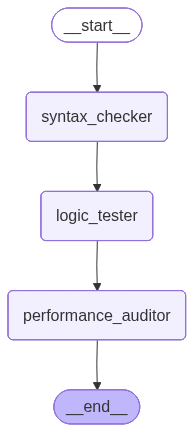


=== PARENT GRAPH ===


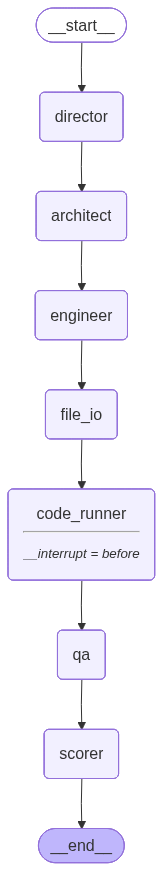

In [23]:
from IPython.display import Image, display

print("=== QA SUBGRAPH ===")
display(Image(qa_subgraph.get_graph().draw_mermaid_png()))

print("\n=== PARENT GRAPH ===")
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
initial_state = {
    "director_messages":  [],
    "architect_messages": [],
    "engineer_code":      [],
    "qa_feedback":        [],
    "current_actor":      "",
    "iteration":          0,
    "iteration_score":    [],
    "file_saved":         False
}

config = {"configurable": {"thread_id": "ec-game-dev-1"}}

# Run until interrupt
print("Starting EC pipeline with QA Subgraph...")
for chunk in graph.stream(initial_state, config=config):
    for node_name, output in chunk.items():
        print(f"\n{'='*40}")
        print(f"AGENT: {node_name.upper()}")
        print(f"{'='*40}")
        if node_name != "__interrupt__":
            print(output)

Starting EC pipeline with QA Subgraph...

AGENT: DIRECTOR
{'director_messages': [HumanMessage(content='Build a fully functional Chrome Dino Runner game using Python and Pygame.  Must include: pterodactyl flying obstacles at different heights,  cactus ground obstacles of different sizes, realistic jumping and  falling physics with gravity, SPACE or UP arrow to jump and DOWN  arrow to duck with hitbox change, and a high score system that  saves across sessions. Single file, no external assets,  use Pygame drawing primitives only.', additional_kwargs={}, response_metadata={}, id='eabc2d58-ecd8-43bb-91e1-3702b8240e88')], 'current_actor': 'director'}

AGENT: ARCHITECT
{'architect_messages': [AIMessage(content='**System Design: Chrome Dino Runner Game**\n==============================================\n\n### 1. Classes\n\n#### a. Player Class\n---------------\n\n*   Attributes:\n    *   `x`, `y`: initial position of the player\n    *   `width`, `height`: dimensions of the player\n    *   `vel

In [25]:
# Run this every time graph pauses at __INTERRUPT__
for chunk in graph.stream(None, config=config):
    for node_name, output in chunk.items():
        print(f"\n{'='*40}")
        print(f"AGENT: {node_name.upper()}")
        print(f"{'='*40}")
        if node_name != "__interrupt__":
            print(output)


===== CODE EXECUTION =====

Executing dino_runner.py...
[Execution Output]: Game ran for 10 seconds — likely working correctly

AGENT: CODE_RUNNER
{'qa_feedback': [AIMessage(content='Execution output:\nGame ran for 10 seconds — likely working correctly', additional_kwargs={}, response_metadata={}, id='1dc70324-5ba6-4142-a168-7d8019d95a43', tool_calls=[], invalid_tool_calls=[])], 'current_actor': 'execution'}

=== Running QA Subgraph ===
[Syntax Checker]: SYNTAX CHECK: PASSED — no syntax errors
[Logic Tester]: Done
[Performance Auditor]: Score 9.5/10
=== QA Subgraph Complete ===


AGENT: QA
{'qa_feedback': [AIMessage(content="=== QA SUBGRAPH REPORT ===\n\nSYNTAX CHECK: PASSED — no syntax errors\n\nLOGIC TEST:\n1. PASS — The player's `jump` method checks if the player is on the ground before allowing a jump, preventing double jumps.\n2. PASS — The player's `duck` method reduces the player's height, effectively reducing their hitbox.\n3. PASS — Cacti are spawned at the ground level, as s